# Transition curve experiments for lifted auto-calibrated pMRI

This notebook contains small-scale synthetic experiments (e.g., Figs. 2-7) for the lifted sparse recovery problem used in the paper:

**Y. Ni & T. Strohmer, “Auto-Calibration and Biconvex Compressive Sensing with Applications to Parallel MRI.”**

These experiments use CVXPY to directly solve the lifted convex recovery problem. The specific optimizer/backend is determined by the `prob.solve(...)` call in the code. The custom iterative FISTA-style solver is not used here; it is used for larger image reconstruction experiments, for example in `lsense.m` and the real-data reconstruction scripts.

The notebook is provided as an archived experiment record. Some result arrays are stored directly in the notebook to avoid rerunning expensive CVXPY solves.

Boundary experiment: measurements L versus basis dimension k and sparsity n

L = number of measurements,
n = sparsity level,
k = calibration / sensitivity basis dimension,
C = number of coils


In [63]:
import numpy as np
import cvxpy as cp
import math
import pywt
from scipy.stats import ortho_group
from scipy.linalg import dft
from scipy.sparse import csc_matrix
from scipy.fftpack import dct
from scipy.signal import cwt

**Solver**

In [ ]:
def solver(L,C,B,Phi):
    """Run synthetic lifted l1,2 recovery over a k-by-n grid.

    This small-scale experiment uses CVXPY to directly solve the lifted
    convex recovery problem. The custom iterative solver used for large image
    reconstructions is not used here.
    """
    for k in range(n_k):
        k = k+1
        for n in range(n_z):
            n = n+1
            succ_rate = 0
            for exp in range(n_exp) :
                succ = 0
                #generate data
                pattern = np.random.choice(N, L,replace=False)
                A = np.asarray([ FFT2[i,:] for i in pattern ])

                #Construct the n sparse z_0
                row = np.random.choice(N, n) #choose n rows without replacement from [0,N)
                column = np.repeat([0],n)
                data =  np.random.randn(n)
                z_0 = csc_matrix((data, (row,column)), shape=(N, 1)).toarray()

                x_0 = Phi.conj().T@z_0
                h_0 = np.random.randn(k,C)
                h_0 /= np.linalg.norm(h_0,axis=0)
                h_vec = np.reshape(h_0,(-1,1),order='F')
                Z_vec = np.kron(z_0, h_0) #Z_vec have vec(h_ix^T) as columns
                B_k = B[:,0:k]
                y_0 = A@((B_k@h_0)*x_0) #get the measurement

                #construct the matrix PB
                PB =  np.zeros((N,k*N),dtype=complex)
                for i in range(N):
                  PB[i,:] = np.kron(Phi[:,i],B_k[i,:].conj().T).conj().T

                P = A @ PB #overall system matrix
                #print('sanity check',np.linalg.norm(P @ Z_vec - y_0))

                #Solving the l1,2 norm optimization problem
                Z = cp.Variable((k*N,C))
                Z_rs = cp.reshape(Z,(N,k*C),order = 'C')
                objective = cp.Minimize(cp.mixed_norm(Z_rs,2,1))
                constraint = [P@Z == y_0]
                #constraint = [cp.norm(A@PB@Z - y_0,2) <= 1e-1] #noisy case
                prob = cp.Problem(objective, constraint)

                prob.solve()
                #prob.solve(solver = cp.MOSEK )
                
                Z_sol = Z.value
                #print('sanity check',np.linalg.norm(P@Z_sol - y_0))

                #Z_recon = np.reshape(Z_sol.T,(-1,N))
                #U,S,V =  np.linalg.svd(Z_recon)
                #recon = np.zeros(N)
                #for i in range(k):
                #  recon += S[i]*V[i,:]
                #recon = np.reshape(Phi@recon,(n_x,n_x))

                succ = np.linalg.norm(Z_sol-Z_vec)/np.linalg.norm(Z_vec)
                #criteria for success
                succ_rate += (succ <=0.01)*1; #1 if the relative error is smaller than 1%
                #datasave.append ( [k,n,exp] (succ <=0.01)*1 norm(Z_0,1) norm(Z_sol,1) rank(full(reshape(Z_0,k,N))) rank(full(reshape(Z_sol,k,N)));

            succ_exp[k-1,n-1] = succ_rate
    return succ_exp

**Plotting**

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as ticker

One-coil case

In [ ]:
C = 1 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [7]:
FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))

In [ ]:
succ_exp = solver(L,C,B,Phi)

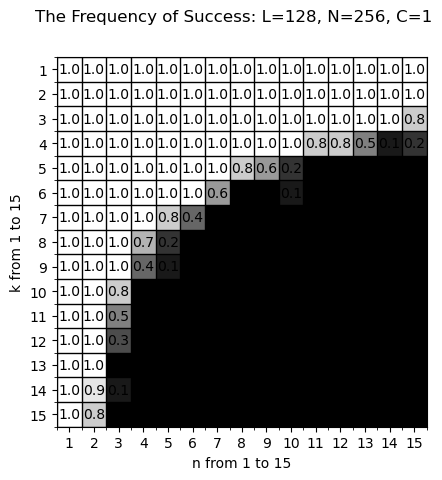

In [19]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))
ax.set_xlabel('n from 1 to 15')
ax.set_ylabel('k from 1 to 15')
plt.imshow(succ_exp,cmap ='gray')
for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

Effect of increasing the number of coils

In [ ]:
C = 2 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))
B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')
succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

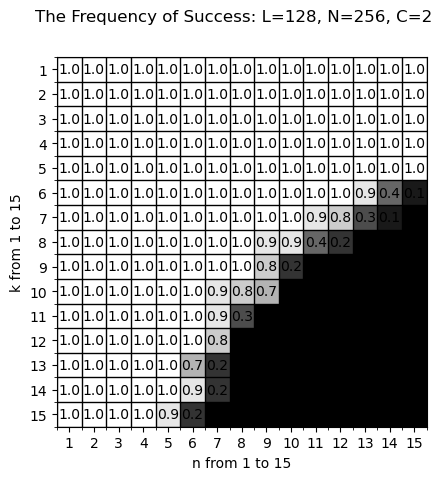

In [10]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))
ax.set_xlabel('n from 1 to 15')
ax.set_ylabel('k from 1 to 15')

plt.imshow(succ_exp,cmap = 'gray')
for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

Additional coil-number comparisons

In [ ]:
C = 4 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))
B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

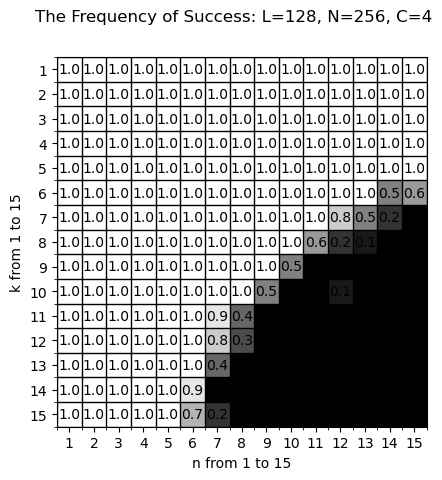

In [25]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))
ax.set_xlabel('n from 1 to 15')
ax.set_ylabel('k from 1 to 15')

plt.imshow(succ_exp,cmap = 'gray')
for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

Exploratory wavelet-basis variant

In [ ]:
import numpy as np
import pywt

def db4_1d_matrix(n):
    """Generate the 1D db4 wavelet transformation matrix for size n."""
    # db4 coefficients from PyWavelets
    wavelet = pywt.Wavelet('db4')
    # Filter coefficients (low-pass and high-pass)
    phi, psi = wavelet.phi, wavelet.psi
    # Length of db4 wavelet filter (it should be 8 for db4)
    filter_len = len(phi)
    
    # Create the wavelet matrix for n elements
    matrix = np.zeros((n, n))
    
    # Fill the matrix with the db4 wavelet coefficients
    for i in range(n):
        for j in range(filter_len):
            if i + j < n:
                matrix[i, i+j] = phi[j]  # Apply scaling filter
                matrix[i, i+j+filter_len] = psi[j]  # Apply wavelet filter

    return matrix

def db4_2d_matrix(N):
    """Generate the 2D db4 wavelet transformation matrix for N x N."""
    # Create 1D transformation matrix for db4
    N_sqrt = int(np.sqrt(N))
    
    # First, apply the db4 1D matrix along the rows
    row_matrix = db4_1d_matrix(N_sqrt)
    
    # Then, apply the db4 1D matrix along the columns
    col_matrix = db4_1d_matrix(N_sqrt).T
    
    # The full 2D transformation matrix is the Kronecker product of the row and column matrices
    return np.kron(row_matrix, col_matrix)

def apply_wavelet_transform(image, N):
    """Apply the db4 2D wavelet transform to a vectorized image."""
    # Flatten the image
    image_vector = image.flatten()
    
    # Generate the 2D db4 wavelet matrix
    wavelet_matrix = db4_2d_matrix(N)
    
    # Apply the transformation by multiplying the wavelet matrix with the image vector
    transformed_image = np.dot(wavelet_matrix, image_vector)
    
    return transformed_image

# Example usage:
N = 64  # Image size N x N (for a 8x8 image)
image = np.random.rand(int(np.sqrt(N)), int(np.sqrt(N)))  # Random N x N image

# Apply the wavelet transform
transformed_image = apply_wavelet_transform(image, N)


Haar/db1 wavelet basis

In [56]:
C = 16 #number of coils
L = 23**2 #number of measurement
n_x = 23
N = n_x**2 #dimension of x
n_k = 3 #max number of basis to use for h
n_z = 3 #max sparsity in z
n_exp = 1 #
wv_name = 'db1'

In [35]:
wavelet = pywt.Wavelet('db1')
print(wavelet)

Wavelet db1
  Family name:    Daubechies
  Short name:     db
  Filters length: 2
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False


In [111]:
N2 = 576
#for db1
W = np.zeros((N2,N)) 
for i in range(N):
    ei = np.zeros((N,))
    ei[i] = 1
    cAn, cHn, cVn = pywt.wavedec2(np.reshape(ei,(n_x,n_x)),wv_name,level = 2)
    cHn = np.asarray(cHn).flatten()
    cVn = np.asarray(cVn).flatten()
    cAn = np.asarray(cAn).flatten()
    aa1 = np.concatenate((cAn, cHn, cVn))
    W[:,i] = aa1
    
weight = np.diag((W.conj().T @ W))
W /= np.sqrt(weight)


In [ ]:
FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))
B = ortho_group.rvs(N)
Phi = W

succ_exp = np.zeros((n_k,n_z))
datasave=[]

### Exploratory wavelet-basis (less coherent) variant, Fig.4

This cell repeats the lifted \( \ell_{1,2} \) recovery experiment using a wavelet dictionary instead of a square orthonormal sparsifying basis. In this setting the sparse coefficient vector has dimension \(N_2\), and the synthesis map \(\Phi^*\) maps wavelet coefficients back to the image domain. 

Daubechies/db4 wavelet basis

In [ ]:
coeffs = pywt.wavedec2(np.ones((16, 16)), 'db4', level=2)
cAn, (cHn, cVn, cDn),(cH1, cV1, cD1) = coeffs
cAn = np.asarray(cAn).flatten()
cHn = np.asarray(cHn).flatten()
cVn = np.asarray(cVn).flatten()
cDn = np.asarray(cDn).flatten()
cH1 = np.asarray(cH1).flatten()
cV1 = np.asarray(cV1).flatten()
cD1 = np.asarray(cD1).flatten()
aa1 = np.concatenate((cAn,cHn,cVn,cDn,cH1,cV1,cD1))
NN2 = len(aa1)
#pywt.waverec2(coeffs, 'db4')

In [ ]:
#for db4
N = 256
res = 16
wv_name = 'db4'
W = np.zeros((NN2,N)) #8 channels
for i in range(N):
    ei = np.zeros((N,))
    ei[i] = 1
    cAn, (cHn, cVn, cDn),(cH1, cV1, cD1) = pywt.wavedec2(np.reshape(ei,(res,res)),wv_name,level = 2)
    cAn = np.asarray(cAn).flatten()
    cHn = np.asarray(cHn).flatten()
    cVn = np.asarray(cVn).flatten()
    cDn = np.asarray(cDn).flatten()
    cH1 = np.asarray(cH1).flatten()
    cV1 = np.asarray(cV1).flatten()
    cD1 = np.asarray(cD1).flatten()
    W[:,i] = np.concatenate((cAn,cHn,cVn,cDn,cH1,cV1,cD1))

In [ ]:
xx = np.random.randint(0,10,(res,res))
coeffs = pywt.wavedec2(xx, 'db4', level=2)
cAn, (cHn, cVn, cDn),(cH1, cV1, cD1) = coeffs
cAn = np.asarray(cAn).flatten()
cHn = np.asarray(cHn).flatten()
cVn = np.asarray(cVn).flatten()
cDn = np.asarray(cDn).flatten()
cH1 = np.asarray(cH1).flatten()
cV1 = np.asarray(cV1).flatten()
cD1 = np.asarray(cD1).flatten()
zz = np.concatenate((cAn,cHn,cVn,cDn,cH1,cV1,cD1))

zz1 = W @ xx.ravel()
xx1 = np.linalg.inv(W.conj().T @ W) @ W.conj().T @ zz1

#print(np.linalg.norm(zz1-zz)) #sanity checks
#print(np.linalg.norm(xx1-xx.ravel()))

In [ ]:
def solver(L,C,B,Phi):
    for k in range(n_k):
        k = k+1
        for n in range(n_z):
            n = n+1
            succ_rate = 0
            for exp in range(n_exp) :
                succ = 0

                #generate data
                #A = np.random.randn(L,N)/L #sampled independently for each exp
                pattern = np.random.choice(N, L,replace=False)
                pattern[0]=0
                A = np.asarray([ FFT2[i,:] for i in pattern ])

                #Construct the n sparse z_0
                row = np.random.choice(NN2, n) #choose n points from [0,wv_channel*N)
                column = np.repeat([0],n)
                data =  np.random.randn(n)
                z_0 = csc_matrix((data, (row,column)), shape=(NN2, 1)).toarray()

                x_0 = Phi.conj().T @z_0
                h_0 = np.random.randn(k,C)
                h_0 /= np.linalg.norm(h_0,axis=0)
                h_vec = np.reshape(h_0,(-1,1),order='F')
                Z_vec = np.kron(z_0, h_0) #Z_vec have vec(h_ix^T) as columns
                #print(Z_vec.shape)
                B_k = B[:,0:k]
                y_0 = A@((B_k@h_0)*x_0) #get the measurement
                
                #construct the matrix PB
                PB =  np.zeros((N,k*NN2),dtype=complex)
                for i in range(N):
    
                  PB[i,:] = np.kron(Phi[:,i],B_k[i,:].conj().T).conj().T
                   
                P = A @ PB #overall system matrix

                #Solving the l1,2 norm optimization problem
                Z = cp.Variable((k*NN2,C))
                Z_rs = cp.reshape(Z,(NN2,k*C),order = 'C')
                objective = cp.Minimize(cp.mixed_norm(Z_rs,2,1))
                constraint = [P@Z == y_0]
                prob = cp.Problem(objective, constraint)

                prob.solve(solver = cp.MOSEK)

                Z_sol = Z.value

                succ = np.linalg.norm(Z_sol.ravel()-Z_vec.ravel())/np.linalg.norm(Z_vec)
                succ_rate += (succ <=0.01)*1; #1 if the relative error is smaller than 1%

            succ_exp[k-1,n-1] = succ_rate
    return succ_exp


In [137]:
C = 1 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 5 #max number of basis to use for h
n_z = 5 #max sparsity in z
n_exp = 10 #

FFT2 = np.kron(np.fft.fft(np.eye(n_x)),np.fft.fft(np.eye(n_x)))
B = ortho_group.rvs(N)
Phi, R = np.linalg.qr(W) #so Phi have orthogonal columns
succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
n_exp = 10 #
succ_exp = solver(L,C,B,Phi)

In [12]:
import matplotlib.pyplot as plt

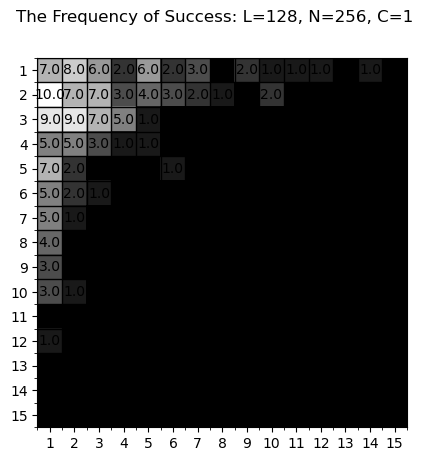

In [13]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

Increasing the number of coils does not significantly improve this wavelet-basis variant.

In [14]:
C = 2 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

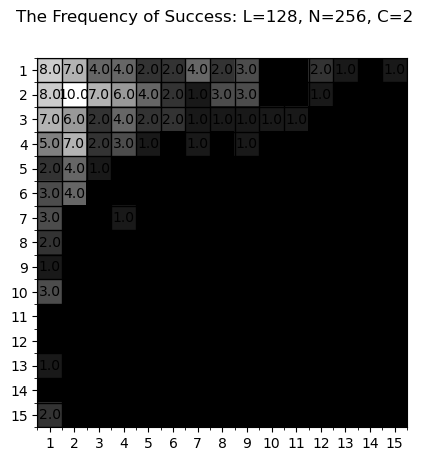

In [17]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

In [18]:
C = 4 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

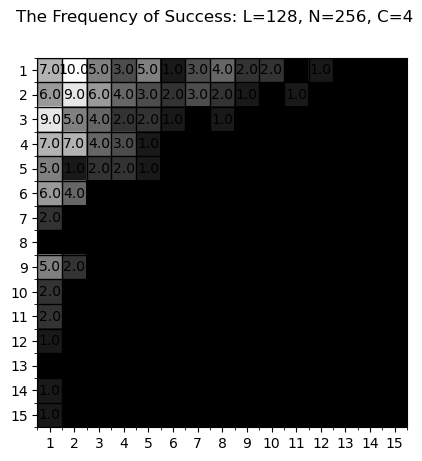

In [21]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L=128, N=256, C={C}')
plt.show()

In [24]:
C = 2 #number of coils
L = 256 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

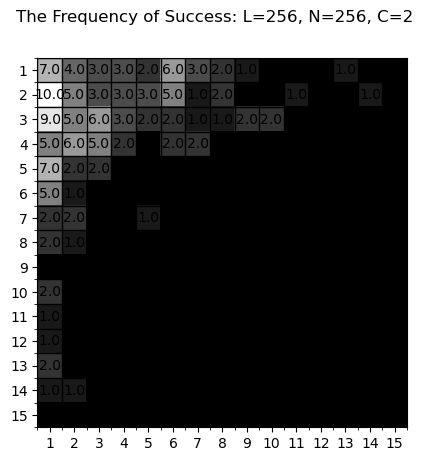

In [28]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L={L}, N=256, C={C}')
plt.show()

Comparison with $\ell_1$ minimization. Reproduces results shown in Fig.5 of the paper.

In [ ]:
C = 1 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')

succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
def solver(L,C,B,Phi):
    """repeat the l1,2 solver, just a different optimization objective.
    """
    for k in range(n_k):
        k = k+1
        for n in range(n_z):
            n = n+1
            succ_rate = 0
            for exp in range(n_exp) :
                succ = 0

                #generate data
                pattern = np.random.choice(N, L,replace=False)
                A = np.asarray([ FFT2[i,:] for i in pattern ])

                #Construct the n sparse z_0
                row = np.random.choice(N, n) #choose n rows from [0,N)
                column = np.repeat([0],n)
                data =  np.random.randn(n)
                z_0 = csc_matrix((data, (row,column)), shape=(N, 1)).toarray()

                x_0 = Phi.conj().T@z_0
                h_0 = np.random.randn(k,C)
                h_0 /= np.linalg.norm(h_0,axis=0)
                h_vec = np.reshape(h_0,(-1,1),order='F')
                Z_vec = np.kron(z_0, h_0) #Z_vec have vec(h_ix^T) as columns
                B_k = B[:,0:k]
                y_0 = A@((B_k@h_0)*x_0) #get the measurement

                #construct the matrix PB
                PB =  np.zeros((N,k*N),dtype=complex)
                for i in range(N):
                  PB[i,:] = np.kron(Phi[:,i],B_k[i,:].conj().T).conj().T

                P = A @ PB #overall system matrix

                #Solving the l1 norm optimization problem
                Z = cp.Variable((k*N,C))
                objective = cp.Minimize(cp.mixed_norm(Z,2,1))
                constraint = [P@Z == y_0]
                prob = cp.Problem(objective, constraint)

                prob.solve()

                Z_sol = Z.value

                succ = np.linalg.norm(Z_sol-Z_vec)/np.linalg.norm(Z_vec)
                succ_rate += (succ <=0.01)*1; #1 if the relative error is smaller than 1%

            succ_exp[k-1,n-1] = succ_rate
    return succ_exp

In [ ]:
succ_exp = solver(L,C,B,Phi)

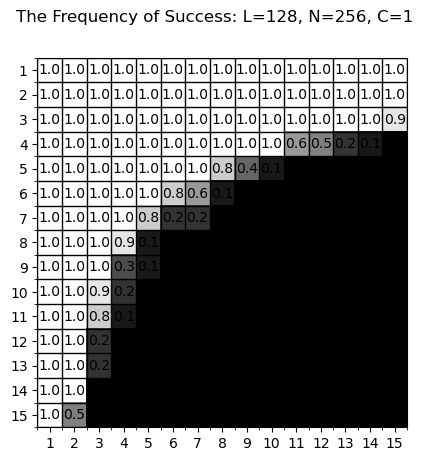

In [11]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L={L}, N=256, C={C}')
plt.show()

In [ ]:
C = 2 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

B = ortho_group.rvs(N)
Phi = dct(np.eye(N),norm='ortho')
succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

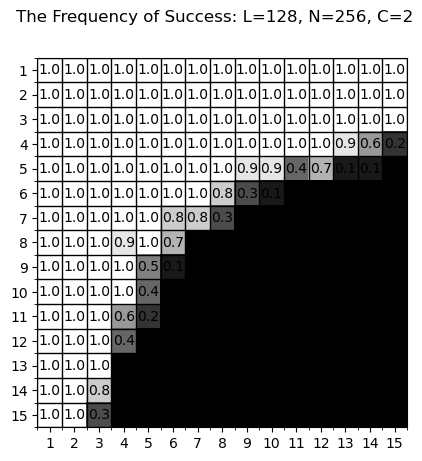

In [14]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L={L}, N=256, C={C}')
plt.show()

In [5]:
C = 4 #number of coils
L = 128 #number of measurement
n_x = 16
N = n_x**2 #dimension of x
n_k = 15 #max number of basis to use for h
n_z = 15 #max sparsity in z
n_exp = 10 #

#B = dft(N,scale='sqrtn') #such that I_N=np.matmul(B.conj().T,B)
B = ortho_group.rvs(N)
#B = np.kron(np.fft.fft(np.eye(12)),np.fft.fft(np.eye(12)));
#Phi = dftmtx(N)/sqrt(N)
Phi = dct(np.eye(N),norm='ortho')
#Phi = ortho_group.rvs(N)
#Phi = pywt.dwt(np.eye(N),'coif1')
#Phi2 = ortho_group.rvs(N)
succ_exp = np.zeros((n_k,n_z))
datasave=[]

In [ ]:
succ_exp = solver(L,C,B,Phi)

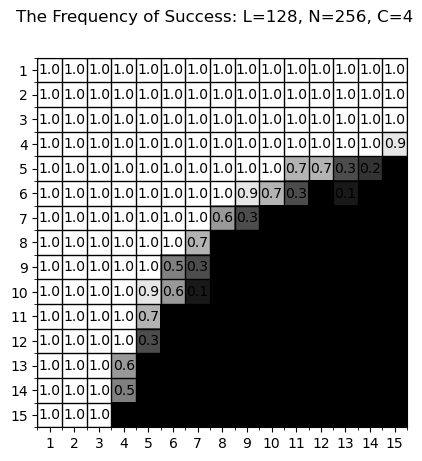

In [10]:
fig, ax = plt.subplots()
ax.grid(which='minor', axis='both', linestyle='-', color='k', linewidth=1)
ax.set_xticks(np.arange(-0.5, n_k, 1),minor = True);
ax.set_yticks(np.arange(-0.5, n_z, 1),minor = True);
ax.set_xticks(np.arange(0,n_k,1))
ax.set_xticklabels(1+np.arange(0,n_k,1))
ax.set_yticks(np.arange(0,n_z,1))
ax.set_yticklabels(1+np.arange(0,n_k,1))
min_val, max_val = 0, 15

intersection_matrix = np.random.randint(0, 15, size=(max_val, max_val))

ax.imshow(succ_exp, cmap = 'gray')

for i in range(15):
    for j in range(15):
        c = succ_exp[j,i]/10
        ax.text(i, j, str(c), va='center', ha='center')

fig.suptitle(f'The Frequency of Success: L={L}, N=256, C={C}')
plt.show()